In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pandas.api.types import CategoricalDtype
import scipy as sp
from pathlib import Path
import tkinter as tk
from tkinter import filedialog
import itertools
from colour import Color
from datetime import date

In [2]:
today = date.today()
print("Today's date:", today)
date = str(today)
date

Today's date: 2026-08-27


'2026-08-27'

## Fig 2 and 4 Replicate clustering - Heatmap ##

Script generates a heatmap similar to hierarchical clustering using .txt files exported directly from Perseus. Running script will open a window prompt to select .txt file, and a second window will prompt save selection.

Heatmap saved to: C:\Users\Brandi\OneDrive\Desktop\Proteomics manuscript\Perseus files for manuscript\Clusters_Fig2_heatmap.svg


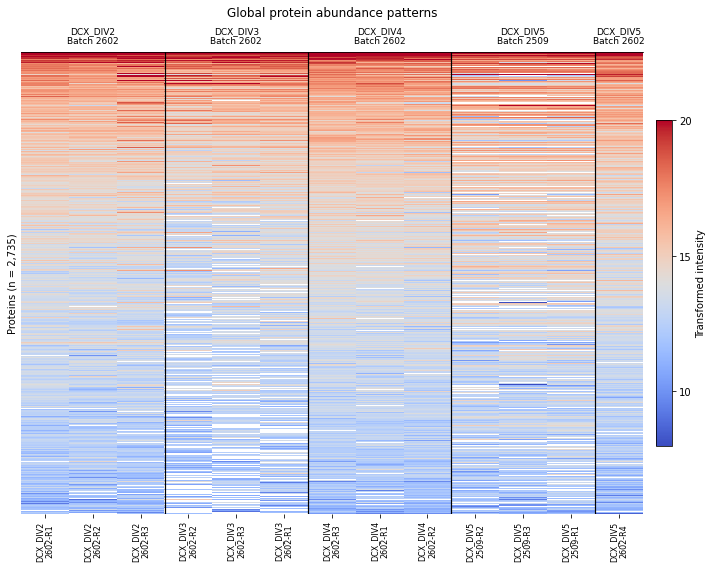


Input matrix: C:\Users\Brandi\OneDrive\Desktop\Proteomics manuscript\Perseus files for manuscript\Clusters_Fig2.txt
Expression columns: 13
Proteins before filtering: 4049
Proteins after completeness filtering: 2735
Proteins used in heatmap: 2735
Processed heatmap matrix saved to: C:\Users\Brandi\OneDrive\Desktop\Proteomics manuscript\Perseus files for manuscript\Clusters_Fig2_heatmap_values.csv
Clustered sample order saved to: C:\Users\Brandi\OneDrive\Desktop\Proteomics manuscript\Perseus files for manuscript\Clusters_Fig2_heatmap_sample_order.csv


In [3]:
from pathlib import Path
from tkinter import Tk, filedialog

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist


# ============================================================
# USER SETTINGS
# ============================================================

# Retain proteins quantified in at least this fraction of samples.
MIN_VALID_FRACTION = 0.70

# Heatmap scale
COLOR_MIN = 8
COLOR_MAX = 20

# Blue → white → red
COLORMAP = "coolwarm"

# Plot size
FIGURE_WIDTH = 10
FIGURE_HEIGHT = 8

# Cluster replicate columns only within each condition × batch.
CLUSTER_WITHIN_CONDITION_AND_BATCH = True

# Pearson correlation distance with average linkage
DISTANCE_METRIC = "correlation"
LINKAGE_METHOD = "average"

# Display options
SHOW_SAMPLE_LABELS = True
SHOW_GROUP_LABELS = True
DRAW_GROUP_SEPARATORS = True


# ============================================================
# SELECT INPUT MATRIX
# ============================================================

root = Tk()
root.withdraw()
root.attributes("-topmost", True)

input_filename = filedialog.askopenfilename(
    title="Select the transformed Perseus matrix",
    filetypes=[
        ("Text files", "*.txt"),
        ("Tab-separated files", "*.tsv"),
        ("All files", "*.*"),
    ],
)

if not input_filename:
    root.destroy()
    raise SystemExit("No file selected.")

input_path = Path(input_filename)


# ============================================================
# READ PERSEUS HEADER AND METADATA ROWS
# ============================================================

with input_path.open(
    "r",
    encoding="utf-8-sig",
    errors="replace",
) as file:

    column_names = file.readline().rstrip("\n\r").split("\t")
    type_row = file.readline().rstrip("\n\r").split("\t")
    condition_row = file.readline().rstrip("\n\r").split("\t")
    replicate_row = file.readline().rstrip("\n\r").split("\t")


# Remove Perseus metadata labels.
type_row[0] = type_row[0].replace("#!{Type}", "")

condition_row[0] = condition_row[0].replace(
    "#!{C:Condition}",
    "",
)

replicate_row[0] = replicate_row[0].replace(
    "#!{C:Replicate}",
    "",
)


# Pad rows in case trailing blank cells were omitted.
number_of_columns = len(column_names)

type_row += [""] * (
    number_of_columns - len(type_row)
)

condition_row += [""] * (
    number_of_columns - len(condition_row)
)

replicate_row += [""] * (
    number_of_columns - len(replicate_row)
)


# ============================================================
# IDENTIFY EXPRESSION COLUMNS
# ============================================================

expression_indices = [
    index
    for index, column_type in enumerate(type_row)
    if column_type.strip() == "E"
]

if not expression_indices:
    root.destroy()
    raise ValueError(
        "No expression columns marked 'E' were found."
    )


expression_columns = [
    column_names[index]
    for index in expression_indices
]

conditions = [
    condition_row[index].strip()
    for index in expression_indices
]

replicates = [
    replicate_row[index].strip()
    for index in expression_indices
]


# ============================================================
# EXTRACT BATCH FROM EACH SAMPLE FILENAME
#
# Examples:
# 2602_DCX_DIV3_1_uncalibrated.mzML → batch 2602
# 2509_R178L_DIV5_2_uncalibrated.mzML → batch 2509
# ============================================================

def extract_batch(column_name):
    filename = Path(column_name).name
    return filename.split("_")[0]


batches = [
    extract_batch(column_name)
    for column_name in expression_columns
]


# ============================================================
# READ THE EXPRESSION MATRIX
# ============================================================

data = pd.read_csv(
    input_path,
    sep="\t",
    skiprows=4,
    names=column_names,
    low_memory=False,
)

expression = data.iloc[
    :,
    expression_indices,
].copy()

expression = expression.apply(
    pd.to_numeric,
    errors="coerce",
)


# ============================================================
# VALUES ARE ALREADY TRANSFORMED
# ============================================================

# Do not log-transform.
# Do not centre around row means.
# Do not remove zero or negative values.
expression_transformed = expression.copy()


# ============================================================
# FILTER PROTEINS BY COMPLETENESS
# ============================================================

minimum_valid_samples = int(
    np.ceil(
        len(expression_columns)
        * MIN_VALID_FRACTION
    )
)

valid_counts = expression_transformed.notna().sum(
    axis=1
)

expression_filtered = expression_transformed.loc[
    valid_counts >= minimum_valid_samples
].copy()

if expression_filtered.empty:
    root.destroy()
    raise ValueError(
        "No proteins remained after filtering. "
        "Lower MIN_VALID_FRACTION."
    )


# # ============================================================
# # IMPUTE REMAINING MISSING VALUES
# # ============================================================

# # Median imputation is used only so clustering and plotting
# # can operate on a complete matrix.
# protein_medians = expression_filtered.median(
#     axis=1
# )

# expression_imputed = (
#     expression_filtered
#     .T
#     .fillna(protein_medians)
#     .T
# )


# # Remove proteins with zero variance.
# protein_variance = expression_imputed.var(
#     axis=1
# )

# expression_imputed = expression_imputed.loc[
#     protein_variance > 0
# ].copy()


# ============================================================
# KEEP MISSING VALUES
# ============================================================

# Do not impute NaNs.
expression_for_heatmap = expression_filtered.copy()

# Remove only rows that are entirely missing.
expression_for_heatmap = expression_for_heatmap.loc[
    expression_for_heatmap.notna().any(axis=1)
].copy()

# ============================================================
# CREATE SAMPLE METADATA
# ============================================================

sample_metadata = pd.DataFrame(
    {
        "Column": expression_columns,
        "Condition": conditions,
        "Batch": batches,
        "Replicate": replicates,
        "Original_Index": np.arange(
            len(expression_columns)
        ),
    }
)


sample_metadata["Sample_Label"] = [
    f"{condition}\n{batch}-R{replicate}"
    for condition, batch, replicate in zip(
        sample_metadata["Condition"],
        sample_metadata["Batch"],
        sample_metadata["Replicate"],
    )
]


# ============================================================
# DETERMINE CONDITION × BATCH GROUP ORDER
#
# Conditions and batches remain in first-occurrence order.
# ============================================================

group_keys = list(
    dict.fromkeys(
        zip(
            sample_metadata["Condition"],
            sample_metadata["Batch"],
        )
    )
)


# ============================================================
# CLUSTER REPLICATES WITHIN EACH CONDITION × BATCH
# ============================================================

ordered_indices = []
group_blocks = []

current_position = 0


for condition, batch in group_keys:

    group_rows = sample_metadata.loc[
        (
            sample_metadata["Condition"] == condition
        )
        &
        (
            sample_metadata["Batch"] == batch
        )
    ].copy()

    group_indices = group_rows[
        "Original_Index"
    ].tolist()


    if (
        CLUSTER_WITHIN_CONDITION_AND_BATCH
        and len(group_indices) > 1
    ):

        # Samples must be rows and proteins must be columns.
        group_matrix = expression_for_heatmap.iloc[
            :,
            group_indices,
        ].T.to_numpy()


        # Pearson distance is 1 - Pearson correlation.
        distances = pdist(
            group_matrix,
            metric=DISTANCE_METRIC,
        )


        # Correlation can be undefined if a sample has no variance.
        if np.all(np.isfinite(distances)):

            linkage_matrix = linkage(
                distances,
                method=LINKAGE_METHOD,
            )

            leaf_order = leaves_list(
                linkage_matrix
            )

            group_indices = [
                group_indices[index]
                for index in leaf_order
            ]


    ordered_indices.extend(
        group_indices
    )


    group_length = len(group_indices)

    group_blocks.append(
        {
            "condition": condition,
            "batch": batch,
            "start": current_position,
            "end": (
                current_position
                + group_length
                - 1
            ),
            "centre": (
                current_position
                + (
                    group_length - 1
                ) / 2
            ),
        }
    )

    current_position += group_length


# ============================================================
# REORDER SAMPLES
# ============================================================

ordered_metadata = (
    sample_metadata
    .set_index("Original_Index")
    .loc[ordered_indices]
    .reset_index()
)

heatmap_data = expression_for_heatmap.iloc[
    :,
    ordered_indices,
].copy()

heatmap_data.columns = ordered_metadata[
    "Sample_Label"
].tolist()


# ============================================================
# OPTIONAL ROW ORDERING
#
# No hierarchical clustering is applied to proteins.
# Proteins are sorted by their overall mean transformed value.
# ============================================================

row_means = heatmap_data.mean(
    axis=1
)

heatmap_data = heatmap_data.loc[
    row_means.sort_values(
        ascending=False
    ).index
]


# ============================================================
# SAVE PROCESSED HEATMAP MATRIX AND SAMPLE ORDER
# ============================================================

matrix_output_path = input_path.with_name(
    f"{input_path.stem}_heatmap_values.csv"
)

heatmap_data.to_csv(
    matrix_output_path,
    index=False,
)


sample_order_output_path = input_path.with_name(
    f"{input_path.stem}_heatmap_sample_order.csv"
)

ordered_metadata[
    [
        "Sample_Label",
        "Condition",
        "Batch",
        "Replicate",
        "Column",
    ]
].to_csv(
    sample_order_output_path,
    index=False,
)


# ============================================================
# DRAW HEATMAP
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        FIGURE_WIDTH,
        FIGURE_HEIGHT,
    )
)


image = ax.imshow(
    heatmap_data.to_numpy(),
    aspect="auto",
    interpolation="nearest",
    cmap=COLORMAP,
    vmin=COLOR_MIN,
    vmax=COLOR_MAX,
)


# ============================================================
# AXIS LABELS
# ============================================================

ax.set_yticks([])

ax.set_ylabel(
    f"Proteins (n = {len(heatmap_data):,})"
)


if SHOW_SAMPLE_LABELS:

    ax.set_xticks(
        np.arange(
            len(ordered_metadata)
        )
    )

    ax.set_xticklabels(
        ordered_metadata[
            "Sample_Label"
        ],
        rotation=90,
        ha="center",
        fontsize=8,
    )

else:

    ax.set_xticks([])


# ============================================================
# DRAW CONDITION × BATCH SEPARATORS
# ============================================================

if DRAW_GROUP_SEPARATORS:

    for block in group_blocks[:-1]:

        ax.axvline(
            block["end"] + 0.5,
            color="black",
            linewidth=1.2,
        )


# ============================================================
# ADD CONDITION × BATCH LABELS ABOVE HEATMAP
# ============================================================

if SHOW_GROUP_LABELS:

    top_axis = ax.secondary_xaxis(
        "top"
    )

    top_axis.set_xticks(
        [
            block["centre"]
            for block in group_blocks
        ]
    )

    top_axis.set_xticklabels(
        [
            (
                f"{block['condition']}\n"
                f"Batch {block['batch']}"
            )
            for block in group_blocks
        ],
        fontsize=9,
    )

    top_axis.tick_params(
        axis="x",
        length=0,
        pad=7,
    )


# ============================================================
# COLOR BAR
# ============================================================

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.025,
    pad=0.02,
)

colorbar.set_label(
    "Transformed intensity"
)

colorbar.set_ticks(
    [0, 5, 10, 15, 20, 26]
)


# ============================================================
# FINAL FORMATTING
# ============================================================

ax.set_title(
    "Global protein abundance patterns",
    pad=36,
)

for spine in ax.spines.values():
    spine.set_visible(False)

fig.tight_layout()


# ============================================================
# SELECT OUTPUT FILE
# ============================================================

default_plot_name = (
    f"{input_path.stem}_heatmap.svg"
)

output_filename = filedialog.asksaveasfilename(
    title="Save global heatmap",
    initialdir=input_path.parent,
    initialfile=default_plot_name,
    defaultextension=".pdf",
    filetypes=[
        ("PDF vector file", "*.pdf"),
        ("SVG vector file", "*.svg"),
        ("PNG image", "*.png"),
        ("TIFF image", "*.tiff"),
        ("All files", "*.*"),
    ],
    parent=root,
)


if output_filename:

    output_path = Path(
        output_filename
    )

    save_options = {
        "bbox_inches": "tight",
    }

    if output_path.suffix.lower() in {
        ".png",
        ".tif",
        ".tiff",
        ".jpg",
        ".jpeg",
    }:
        save_options["dpi"] = 600

    fig.savefig(
        output_path,
        **save_options,
    )

    print(
        f"Heatmap saved to: {output_path}"
    )

else:

    print(
        "The heatmap was displayed but not saved."
    )


plt.show()
plt.close(fig)

root.destroy()


# ============================================================
# REPORT PROCESSING INFORMATION
# ============================================================

print()
print(f"Input matrix: {input_path}")
print(f"Expression columns: {len(expression_columns)}")
print(f"Proteins before filtering: {len(expression)}")

print(
    "Proteins after completeness filtering: "
    f"{len(expression_filtered)}"
)

print(
    "Proteins used in heatmap: "
    f"{len(heatmap_data)}"
)

print(
    "Processed heatmap matrix saved to: "
    f"{matrix_output_path}"
)

print(
    "Clustered sample order saved to: "
    f"{sample_order_output_path}"
)

## Figure 2 and 4: Principal component analysis (PCA) ##

Script performed on .txt files exported directly from Perseus. Running script will open window prompt for .txt file selection, and a second window for save selection.

PCA plot saved to: C:\Users\Brandi\OneDrive\Desktop\Proteomics manuscript\Perseus files for manuscript\PCA_Fig2_PCA.svg


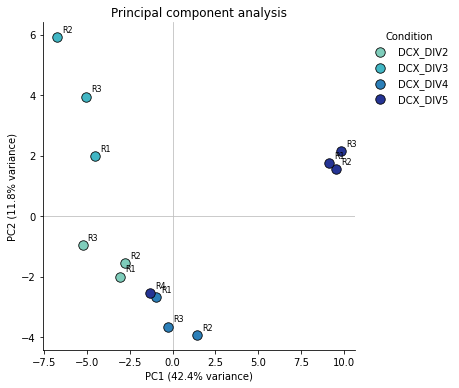


Input matrix: C:\Users\Brandi\OneDrive\Desktop\Proteomics manuscript\Perseus files for manuscript\PCA_Fig2.txt
Expression columns: 13
Proteins before filtering: 4049
Proteins after completeness filtering: 4049
Proteins used for PCA after zero-variance filtering: 4049
PCA coordinates saved to: C:\Users\Brandi\OneDrive\Desktop\Proteomics manuscript\Perseus files for manuscript\PCA_Fig2_PCA_coordinates.csv
Variance table saved to: C:\Users\Brandi\OneDrive\Desktop\Proteomics manuscript\Perseus files for manuscript\PCA_Fig2_PCA_variance.csv


In [6]:
from pathlib import Path
from tkinter import Tk, filedialog

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA


# ============================================================
# USER SETTINGS
# ============================================================

# Your uploaded matrix contains raw intensities, so leave this True.
# Change to False if you use a matrix already transformed to log2.
APPLY_LOG2 = True

# Retain proteins quantified in at least this fraction of samples.
MIN_VALID_FRACTION = 0.70

# Point appearance
POINT_SIZE = 90
POINT_EDGE_WIDTH = 0.8
LABEL_FONT_SIZE = 8

# Optional condition colors.
# Conditions not listed here receive colors automatically.
CONDITION_COLORS = {
    "DCX_DIV2": "#7FCDBB",
    "DCX_DIV3": "#41B6C4",
    "DCX_DIV4": "#2C7FB8",
    "DCX_DIV5": "#253494",
    "R178L_DIV5": "#C2185B",
}


# ============================================================
# SELECT THE PERSEUS MATRIX
# ============================================================

root = Tk()
root.withdraw()
root.attributes("-topmost", True)

input_filename = filedialog.askopenfilename(
    title="Select the Perseus expression matrix",
    filetypes=[
        ("Text files", "*.txt"),
        ("Tab-separated files", "*.tsv"),
        ("All files", "*.*"),
    ],
)

if not input_filename:
    root.destroy()
    raise SystemExit("No file selected.")

input_path = Path(input_filename)


# ============================================================
# READ THE FIRST FOUR PERSEUS HEADER/METADATA ROWS
# ============================================================

with input_path.open(
    "r",
    encoding="utf-8-sig",
    errors="replace",
) as file:

    column_names = file.readline().rstrip("\n\r").split("\t")
    type_row = file.readline().rstrip("\n\r").split("\t")
    condition_row = file.readline().rstrip("\n\r").split("\t")
    replicate_row = file.readline().rstrip("\n\r").split("\t")


# Remove the Perseus labels from the first cell.
type_row[0] = type_row[0].replace("#!{Type}", "")
condition_row[0] = condition_row[0].replace("#!{C:Condition}", "")
replicate_row[0] = replicate_row[0].replace("#!{C:Replicate}", "")


# Pad metadata rows in case trailing empty cells were omitted.
number_of_columns = len(column_names)

type_row += [""] * (number_of_columns - len(type_row))
condition_row += [""] * (number_of_columns - len(condition_row))
replicate_row += [""] * (number_of_columns - len(replicate_row))


# ============================================================
# IDENTIFY EXPRESSION COLUMNS
# ============================================================

expression_indices = [
    index
    for index, column_type in enumerate(type_row)
    if column_type.strip() == "E"
]

if not expression_indices:
    root.destroy()
    raise ValueError(
        "No expression columns marked 'E' were found in the Type row."
    )

expression_columns = [
    column_names[index]
    for index in expression_indices
]

conditions = [
    condition_row[index].strip()
    for index in expression_indices
]

replicates = [
    replicate_row[index].strip()
    for index in expression_indices
]


# ============================================================
# READ THE NUMERIC MATRIX
# ============================================================

data = pd.read_csv(
    input_path,
    sep="\t",
    skiprows=4,
    names=column_names,
    low_memory=False,
)

expression = data.iloc[:, expression_indices].copy()

# Convert everything in expression columns to numeric.
expression = expression.apply(
    pd.to_numeric,
    errors="coerce",
)


# ============================================================
# REMOVE INVALID VALUES AND LOG2-TRANSFORM
# ============================================================

# Intensities of zero cannot be log2-transformed.
# expression = expression.mask(expression <= 0)

if APPLY_LOG2:
    expression = np.log2(expression)


# ============================================================
# FILTER PROTEINS BY COMPLETENESS
# ============================================================

minimum_valid_samples = int(
    np.ceil(len(expression_columns) * MIN_VALID_FRACTION)
)

valid_counts = expression.notna().sum(axis=1)

expression_filtered = expression.loc[
    valid_counts >= minimum_valid_samples
].copy()

if expression_filtered.empty:
    root.destroy()
    raise ValueError(
        "No proteins remained after missing-value filtering. "
        "Lower MIN_VALID_FRACTION."
    )


# ============================================================
# IMPUTE REMAINING MISSING VALUES
# ============================================================

# Median imputation is used here only to permit PCA.
# Each missing protein intensity is replaced by that protein's
# median across all retained samples.
protein_medians = expression_filtered.median(axis=1)

expression_for_heatmap = expression_filtered.T.fillna(
    protein_medians
).T


# Remove proteins with zero variance across all samples.
protein_variance = expression_for_heatmap.var(axis=1)

expression_for_heatmap = expression_for_heatmap.loc[
    protein_variance > 0
]


# ============================================================
# PERFORM PCA
#
# Rows must be samples and columns must be proteins.
# sklearn PCA automatically mean-centers each protein.
# ============================================================

sample_matrix = expression_for_heatmap.T

pca = PCA(n_components=2)

principal_components = pca.fit_transform(
    sample_matrix
)

variance_explained = (
    pca.explained_variance_ratio_ * 100
)


# ============================================================
# CREATE SAMPLE METADATA
# ============================================================

sample_names = []

for column_name, condition, replicate in zip(
    expression_columns,
    conditions,
    replicates,
):
    sample_name = Path(column_name).stem

    sample_name = sample_name.replace(
        "_uncalibrated",
        "",
    )

    sample_names.append(sample_name)


pca_results = pd.DataFrame(
    {
        "Sample": sample_names,
        "Condition": conditions,
        "Replicate": replicates,
        "PC1": principal_components[:, 0],
        "PC2": principal_components[:, 1],
    }
)


# Save PCA coordinates automatically beside the input matrix.
coordinates_path = input_path.with_name(
    f"{input_path.stem}_PCA_coordinates.csv"
)

pca_results.to_csv(
    coordinates_path,
    index=False,
)


# Also save variance explained.
variance_path = input_path.with_name(
    f"{input_path.stem}_PCA_variance.csv"
)

pd.DataFrame(
    {
        "Principal_Component": [
            f"PC{i + 1}"
            for i in range(len(pca.explained_variance_ratio_))
        ],
        "Variance_Explained_Percent":
            pca.explained_variance_ratio_ * 100,
    }
).to_csv(
    variance_path,
    index=False,
)


# ============================================================
# PLOT PC1 AGAINST PC2
# ============================================================

fig, ax = plt.subplots(
    figsize=(6.5, 5.5)
)


unique_conditions = list(
    dict.fromkeys(conditions)
)

automatic_colors = plt.cm.tab10(
    np.linspace(
        0,
        1,
        len(unique_conditions),
    )
)


for color_index, condition in enumerate(unique_conditions):

    subset = pca_results.loc[
        pca_results["Condition"] == condition
    ]

    point_color = CONDITION_COLORS.get(
        condition,
        automatic_colors[color_index],
    )

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        s=POINT_SIZE,
        color=point_color,
        edgecolor="black",
        linewidth=POINT_EDGE_WIDTH,
        label=condition,
        zorder=3,
    )

    # Label each point with its replicate number.
    for _, row in subset.iterrows():

        ax.annotate(
            f"R{row['Replicate']}",
            xy=(
                row["PC1"],
                row["PC2"],
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=LABEL_FONT_SIZE,
        )


ax.axhline(
    0,
    linewidth=0.8,
    color="0.75",
    zorder=1,
)

ax.axvline(
    0,
    linewidth=0.8,
    color="0.75",
    zorder=1,
)


ax.set_xlabel(
    f"PC1 ({variance_explained[0]:.1f}% variance)"
)

ax.set_ylabel(
    f"PC2 ({variance_explained[1]:.1f}% variance)"
)

ax.set_title("Principal component analysis")

ax.legend(
    title="Condition",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()


# ============================================================
# SELECT WHERE AND HOW TO SAVE THE PCA PLOT
# ============================================================

default_plot_name = (
    f"{input_path.stem}_PCA.pdf"
)

output_filename = filedialog.asksaveasfilename(
    title="Save PCA plot",
    initialdir=input_path.parent,
    initialfile=default_plot_name,
    defaultextension=".pdf",
    filetypes=[
        ("PDF vector file", "*.pdf"),
        ("SVG vector file", "*.svg"),
        ("PNG image", "*.png"),
        ("TIFF image", "*.tiff"),
        ("All files", "*.*"),
    ],
    parent=root,
)


if output_filename:

    output_path = Path(output_filename)

    save_options = {
        "bbox_inches": "tight",
    }

    if output_path.suffix.lower() in {
        ".png",
        ".tif",
        ".tiff",
        ".jpg",
        ".jpeg",
    }:
        save_options["dpi"] = 600

    fig.savefig(
        output_path,
        **save_options,
    )

    print(f"PCA plot saved to: {output_path}")

else:
    print("The PCA plot was displayed but not saved.")


plt.show()
plt.close(fig)

root.destroy()


# ============================================================
# REPORT PROCESSING DETAILS
# ============================================================

print()
print(f"Input matrix: {input_path}")
print(f"Expression columns: {len(expression_columns)}")
print(f"Proteins before filtering: {len(expression)}")
print(
    "Proteins after completeness filtering: "
    f"{len(expression_filtered)}"
)
print(
    "Proteins used for PCA after zero-variance filtering: "
    f"{len(expression_for_heatmap)}"
)
print(f"PCA coordinates saved to: {coordinates_path}")
print(f"Variance table saved to: {variance_path}")